In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [3]:
df = pd.read_csv("train_revised.csv")

print("Dataset Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

Dataset Shape: (51645, 10)

Columns:
['ride_id', 'seat_number', 'payment_method', 'payment_receipt', 'travel_date', 'travel_time', 'travel_from', 'travel_to', 'car_type', 'max_capacity']

First 5 rows:


,ride_id,seat_number,payment_method,payment_receipt,travel_date,travel_time,travel_from,travel_to,car_type,max_capacity
0,1442,15A,Mpesa,UZUEHCBUSO,17-10-17,7:15,Migori,Nairobi,Bus,49
1,5437,14A,Mpesa,TIHLBUSGTE,19-11-17,7:12,Migori,Nairobi,Bus,49
2,5710,8B,Mpesa,EQX8Q5G19O,26-11-17,7:05,Keroka,Nairobi,Bus,49
3,5777,19A,Mpesa,SGP18CL0ME,27-11-17,7:10,Homa Bay,Nairobi,Bus,49
4,5778,11A,Mpesa,BM97HFRGL9,27-11-17,7:12,Migori,Nairobi,Bus,49


In [ ]:
print(df.isnull().sum())

In [4]:
df['travel_date'] = pd.to_datetime(
    df['travel_date'],
    format='%d-%m-%y'
)

df['hour'] = pd.to_datetime(
    df['travel_time'],
    format='%H:%M'
).dt.hour

In [5]:
ride_df = df.groupby('ride_id').agg(
    passenger_demand=('ride_id', 'size'),
    travel_date=('travel_date', 'first'),
    travel_time=('travel_time', 'first'),
    travel_from=('travel_from', 'first'),
    travel_to=('travel_to', 'first'),
    car_type=('car_type', 'first'),
    max_capacity=('max_capacity', 'first'),
    hour=('hour', 'first')
).reset_index()

In [6]:
print("Number of rides:", len(ride_df))

display(ride_df.head())

Number of rides: 6249


,ride_id,passenger_demand,travel_date,travel_time,travel_from,travel_to,car_type,max_capacity,hour
0,1442,1,2017-10-17,7:15,Migori,Nairobi,Bus,49,7
1,5437,1,2017-11-19,7:12,Migori,Nairobi,Bus,49,7
2,5710,1,2017-11-26,7:05,Keroka,Nairobi,Bus,49,7
3,5777,5,2017-11-27,7:10,Homa Bay,Nairobi,Bus,49,7
4,5778,31,2017-11-27,7:12,Migori,Nairobi,Bus,49,7


In [7]:
ride_df['day_of_week'] = ride_df['travel_date'].dt.dayofweek
ride_df['month'] = ride_df['travel_date'].dt.month
ride_df['day'] = ride_df['travel_date'].dt.day

ride_df['is_weekend'] = (
    ride_df['day_of_week'] >= 5
).astype(int)

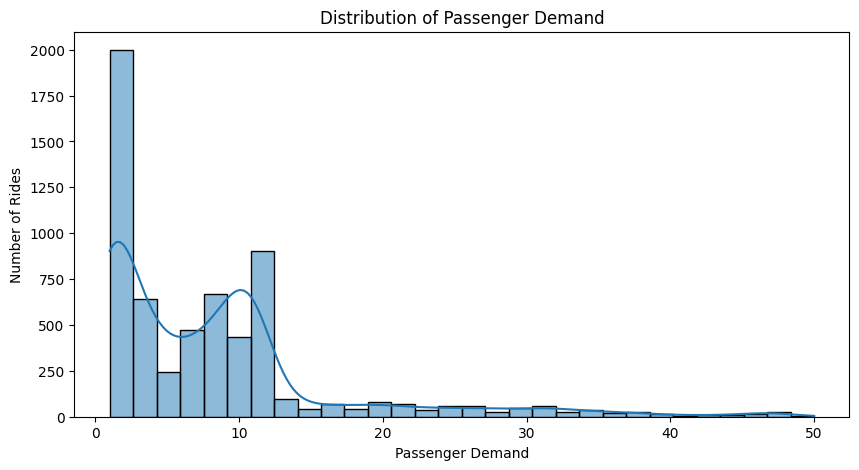

In [8]:
plt.figure(figsize=(10,5))

sns.histplot(
    ride_df['passenger_demand'],
    bins=30,
    kde=True
)

plt.title("Distribution of Passenger Demand")
plt.xlabel("Passenger Demand")
plt.ylabel("Number of Rides")

plt.show()

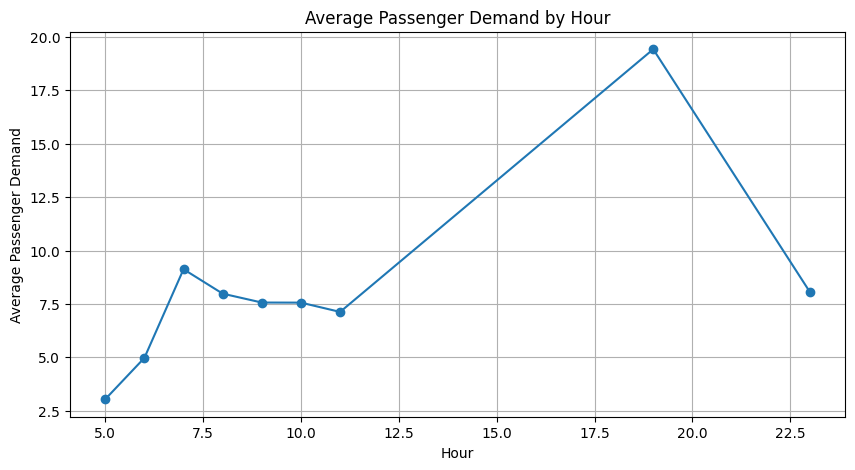

In [9]:
hour_demand = ride_df.groupby(
    'hour'
)['passenger_demand'].mean()

plt.figure(figsize=(10,5))

plt.plot(
    hour_demand.index,
    hour_demand.values,
    marker='o'
)

plt.title("Average Passenger Demand by Hour")
plt.xlabel("Hour")
plt.ylabel("Average Passenger Demand")
plt.grid(True)

plt.show()

In [10]:
features = [
    'hour',
    'day_of_week',
    'month',
    'day',
    'is_weekend',
    'travel_from',
    'car_type',
    'max_capacity'
]

X = ride_df[features]

y = ride_df['passenger_demand']

print("Input features:")
print(X.columns.tolist())

print("\nTarget:")
print("passenger_demand")

Input features:
['hour', 'day_of_week', 'month', 'day', 'is_weekend', 'travel_from', 'car_type', 'max_capacity']

Target:
passenger_demand


In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 4999
Testing samples: 1250


In [12]:
categorical_features = [
    'travel_from',
    'car_type'
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            'categorical',
            OneHotEncoder(handle_unknown='ignore'),
            categorical_features
        )
    ],
    remainder='passthrough'
)

In [13]:
model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('regressor', LinearRegression())
    ]
)

model.fit(X_train, y_train)

/usr/local/lib/python3.13/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('categorical',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['travel_from',
                                                   'car_type'])])),
                ('regressor', LinearRegression())])

In [14]:
y_pred = model.predict(X_test)

print("Prediction completed successfully!")

Prediction completed successfully!


In [15]:
mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(
    mean_squared_error(y_test, y_pred)
)

r2 = r2_score(y_test, y_pred)

print("Model Performance")
print("----------------------------")
print("MAE  :", round(mae, 2))
print("RMSE :", round(rmse, 2))
print("R²   :", round(r2, 2))

Model Performance
----------------------------
MAE  : 4.89
RMSE : 7.16
R²   : 0.37


In [16]:
results = pd.DataFrame({
    'Actual Passenger Demand': y_test.values,
    'Predicted Passenger Demand': y_pred
})

display(results.head(10))

,Actual Passenger Demand,Predicted Passenger Demand
0,11,8.090838
1,11,8.105380
2,8,4.828327
3,3,8.300528
4,4,6.635119
5,10,7.868300
6,10,3.635243
7,1,3.502754
8,3,4.503683
9,1,12.469981


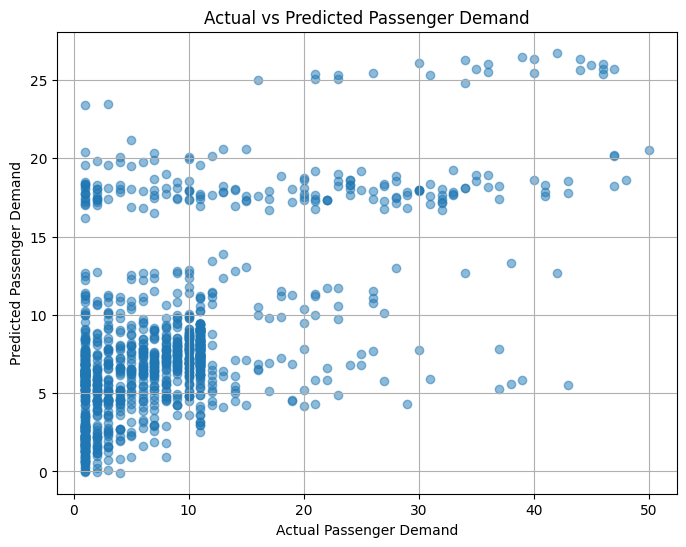

In [17]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.5
)

plt.xlabel("Actual Passenger Demand")
plt.ylabel("Predicted Passenger Demand")

plt.title("Actual vs Predicted Passenger Demand")

plt.grid(True)

plt.show()

In [18]:
new_ride = pd.DataFrame({
    'hour': [8],
    'day_of_week': [1],
    'month': [3],
    'day': [15],
    'is_weekend': [0],
    'travel_from': ['Kisii'],
    'car_type': ['Bus'],
    'max_capacity': [49]
})

predicted_demand = model.predict(new_ride)

print(
    "Predicted Passenger Demand:",
    round(predicted_demand[0], 2)
)

Predicted Passenger Demand: 6.89
